# Notebook 3 - Gradient descent, momentum and adaptive methods

Project 1, parts e and f.

Anne Kristin Furu, FYS-STK4155, fall 2026.

## Setup

In [ ]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
from jax import grad
from common import BLUE, RED, YELLOW, GREY, GREEN, SEED, savefig
from Get_data import make_data, polynomial_features, scale_center, split
from helper import ols_ridge_cost, ols_ridge_gradient, hessian_eigs, learning_rate_bounds
from optimisers import optimise, optimiser_step
from OLS import ols_svd
from Ridge import ridge_closed_form
np.set_printoptions(precision=4, suppress=True)

x, y = make_data(n=100, noise=0.1, seed=SEED)

## Part e: gradient descent with analytical and automatic gradients

We fit Runge with gradient descent instead of the closed form. First we check the gradient two ways, then we study the learning rate.

### The gradient two ways

The analytical gradient of the OLS cost is $\frac{2}{n}X^T(X\theta-y)$, and for Ridge it has the extra term $2\lambda\theta$. We compare it with `jax.grad` of the same cost at a random $\theta$. They agree to machine precision.

In [ ]:
d = 6
X = polynomial_features(x, d)
Xtr, Xte, ytr, yte = split(X, y, test_size=0.2, seed=SEED)
Xtr, Xte, ytr, yte, _ = scale_center(Xtr, Xte, ytr, yte)
lam = 1e-3

def cost_ols(th, X, y):
    return jnp.sum((X @ th - y) ** 2) / len(y)

def cost_ridge(th, X, y, lam):
    return jnp.sum((X @ th - y) ** 2) / len(y) + lam * jnp.sum(th ** 2)


rng = np.random.default_rng(SEED)
th = rng.standard_normal(Xtr.shape[1])
Xj, yj = jnp.asarray(Xtr), jnp.asarray(ytr)

g_ad_ols = np.asarray(grad(cost_ols)(th, Xj, yj))
g_an_ols = ols_ridge_gradient(th, Xtr, ytr, 0.0)
g_ad_ridge = np.asarray(grad(cost_ridge)(th, Xj, yj, lam))
g_an_ridge = ols_ridge_gradient(th, Xtr, ytr, lam)
print('OLS   max |AD - analytical| =', np.max(np.abs(g_ad_ols - g_an_ols)))
print('Ridge max |AD - analytical| =', np.max(np.abs(g_ad_ridge - g_an_ridge)))

OLS   max |AD - analytical| = 2.220446049250313e-16
Ridge max |AD - analytical| = 2.220446049250313e-16


Automatic differentiation is neither symbolic nor finite-difference. It applies the exact chain rule through the code, with no closed-form expression and no step size, so the result is exact. In reverse mode a full gradient costs about two or three cost evaluations whatever the number of parameters. Because the two gradients agree, gradient descent gives the same iterates with either one.

### Learning rate and the eigenvalues of the Hessian

On the degree-4 problem we run plain gradient descent for several learning rates and compare with the closed-form OLS solution. Section 4.5 says gradient descent converges only for $\gamma < 2/\lambda_{\max}$, is fastest at $\gamma^\ast = 2/(\lambda_{\max}+\lambda_{\min})$, and slows down as the condition number grows. We verify the stability edge numerically.

degree 4: kappa=64.5, gamma_max=0.3930, gamma*=0.3870


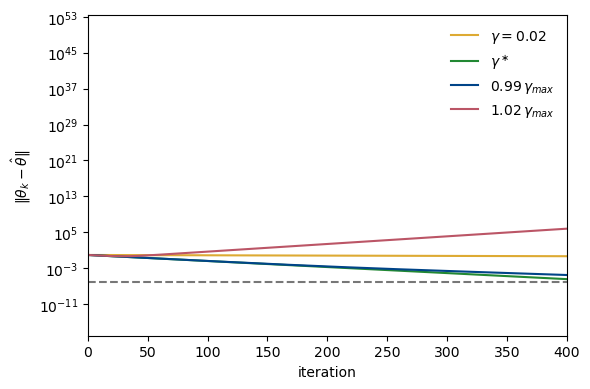

In [ ]:
d = 4
X = polynomial_features(x, d)
Xtr, Xte, ytr, yte = split(X, y, test_size=0.2, seed=SEED)
Xtr, Xte, ytr, yte, _ = scale_center(Xtr, Xte, ytr, yte)
theta_hat = ols_svd(Xtr, ytr)
gmax, gstar, kappa = learning_rate_bounds(Xtr)
print(f'degree {d}: kappa={kappa:.1f}, gamma_max={gmax:.4f}, gamma*={gstar:.4f}')

grad_fn = lambda th: ols_ridge_gradient(th, Xtr, ytr, 0.0)
gammas = [0.02, gstar, 0.99 * gmax, 1.02 * gmax]
labels = [r'$\gamma=0.02$', r'$\gamma^\ast$', r'$0.99\,\gamma_{max}$', r'$1.02\,\gamma_{max}$']
cols = [YELLOW, GREEN, BLUE, RED]

fig, ax = plt.subplots(figsize=(6, 4))
for g, lab, col in zip(gammas, labels, cols):
    hist, _ = optimise(grad_fn, np.zeros(Xtr.shape[1]), 'plain', g, num_iters=3000, tol=0.0)
    dist = np.linalg.norm(hist - theta_hat, axis=1)
    ax.semilogy(dist, color=col, label=lab)
ax.set_xlim(0, 400)
ax.axhline(1e-6, ls='--', color=GREY)
ax.set_xlabel('iteration')
ax.set_ylabel(r'$\|\theta_k - \hat\theta\|$')
ax.legend(frameon=False)
fig.tight_layout()
savefig('e_learning_rate', fig)
plt.show()

The straight lines on the log scale are geometric convergence. The fastest rate is $\gamma^\ast$. Just below the stability edge, $0.99\,\gamma_{max}$, it still converges; just above, $1.02\,\gamma_{max}$, it diverges. The edge is set by the largest eigenvalue of the Hessian, a property of the data, not of the algorithm, so we compute it before choosing the step.

### Automatic gradient in the loop, and Ridge

We now let the automatic gradient drive the same descent as the analytical one, and run gradient descent on Ridge against its closed form. For Ridge the Hessian is $(2/n)X^TX + 2\lambda I$, so the stability bound becomes $2/(\lambda_{\max}+2\lambda)$.

In [ ]:
d = 4
X = polynomial_features(x, d)
Xtr, Xte, ytr, yte = split(X, y, test_size=0.2, seed=SEED)
Xtr, Xte, ytr, yte, _ = scale_center(Xtr, Xte, ytr, yte)
Xj, yj = jnp.asarray(Xtr), jnp.asarray(ytr)

# (1) OLS: analytical vs automatic gradient driving the same descent
theta_hat = ols_svd(Xtr, ytr)
gmax, gstar, kappa = learning_rate_bounds(Xtr)
grad_an = lambda th: ols_ridge_gradient(th, Xtr, ytr, 0.0)
grad_ad = lambda th: np.asarray(grad(cost_ols)(jnp.asarray(th), Xj, yj))
hist_an, _ = optimise(grad_an, np.zeros(Xtr.shape[1]), 'plain', gstar, num_iters=2000, tol=1e-10)
hist_ad, _ = optimise(grad_ad, np.zeros(Xtr.shape[1]), 'plain', gstar, num_iters=2000, tol=1e-10)
print(f'OLS, degree {d}, gamma*={gstar:.4f}:')
print(f'  analytical gradient: {len(hist_an)-1} iterations, |theta - closed form| = {np.linalg.norm(hist_an[-1]-theta_hat):.2e}')
print(f'  automatic gradient : {len(hist_ad)-1} iterations, |theta - closed form| = {np.linalg.norm(hist_ad[-1]-theta_hat):.2e}')
m = min(len(hist_an), len(hist_ad))
print(f'  max |iterates differ| = {np.max(np.abs(hist_an[:m] - hist_ad[:m])):.2e}')

# (2) Ridge: gradient descent against the closed form, bound 2/(lambda_max + 2 lam)
lam = 1e-2
theta_ridge = ridge_closed_form(Xtr, ytr, lam)
eigs_r = hessian_eigs(Xtr, lam)
gmax_r = 2.0 / eigs_r.max()
gstar_r = 2.0 / (eigs_r.max() + eigs_r.min())
grad_r = lambda th: ols_ridge_gradient(th, Xtr, ytr, lam)
hist_r, _ = optimise(grad_r, np.zeros(Xtr.shape[1]), 'plain', gstar_r, num_iters=2000, tol=1e-10)
print(f'\nRidge, lambda={lam}: kappa={eigs_r.max()/eigs_r.min():.1f}, gamma_max=2/(lambda_max+2*lam)={gmax_r:.4f}, gamma*={gstar_r:.4f}')
print(f'  {len(hist_r)-1} iterations, |theta - Ridge closed form| = {np.linalg.norm(hist_r[-1]-theta_ridge):.2e}')
for g in (0.99 * gmax_r, 1.02 * gmax_r):
    with np.errstate(over='ignore', invalid='ignore'):
        h, _ = optimise(grad_r, np.zeros(Xtr.shape[1]), 'plain', g, num_iters=2000, tol=0.0)
    dist = np.linalg.norm(h[-1] - theta_ridge)
    print(f'  gamma = {g/gmax_r:.2f} * gamma_max -> final distance {dist:.2e} ({"converges" if dist < 1e-3 else "diverges"})')

OLS, degree 4, gamma*=0.3870:
  analytical gradient: 722 iterations, |theta - closed form| = 1.66e-10
  automatic gradient : 722 iterations, |theta - closed form| = 1.66e-10
  max |iterates differ| = 3.33e-16

Ridge, lambda=0.01: kappa=51.7, gamma_max=2/(lambda_max+2*lam)=0.3915, gamma*=0.3841
  578 iterations, |theta - Ridge closed form| = 1.34e-10
  gamma = 0.99 * gamma_max -> final distance 3.53e-15 (converges)
  gamma = 1.02 * gamma_max -> final distance 1.11e+33 (diverges)


## Part f: momentum, AdaGrad, RMSProp and Adam

We extend gradient descent with momentum and the adaptive methods, and compare them on the harder degree-6 Runge problem, where the condition number is about 2000 and plain gradient descent is slow.

degree 6: kappa=2090
plain     gamma=0.2339 -> 17144 iters to 1e-6
momentum  gamma=0.2339 -> 1572 iters to 1e-6
adagrad   gamma=0.1000 -> did not reach 1e-6
rmsprop   gamma=0.1000 -> did not reach 1e-6
adam      gamma=0.1000 -> 1280 iters to 1e-6


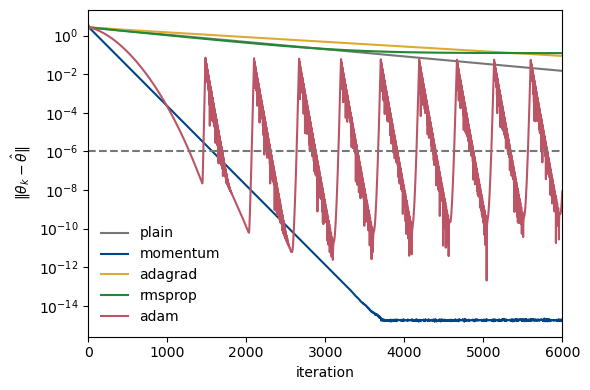

In [ ]:
d = 6
X = polynomial_features(x, d)
Xtr, Xte, ytr, yte = split(X, y, test_size=0.2, seed=SEED)
Xtr, Xte, ytr, yte, _ = scale_center(Xtr, Xte, ytr, yte)
theta_hat = ols_svd(Xtr, ytr)
gmax, gstar, kappa = learning_rate_bounds(Xtr)
grad_fn = lambda th: ols_ridge_gradient(th, Xtr, ytr, 0.0)
print(f'degree {d}: kappa={kappa:.0f}')

def iters_to(hist, tol=1e-6):
    dist = np.linalg.norm(hist - theta_hat, axis=1)
    hit = np.argmax(dist < tol)
    return int(hit) if dist[hit] < tol else None

runs = [('plain', 0.9 * gmax), ('momentum', 0.9 * gmax),
        ('adagrad', 0.1), ('rmsprop', 0.1), ('adam', 0.1)]
cols = {'plain': GREY, 'momentum': BLUE, 'adagrad': YELLOW, 'rmsprop': GREEN, 'adam': RED}

fig, ax = plt.subplots(figsize=(6, 4))
for method, g in runs:
    hist, _ = optimise(grad_fn, np.zeros(Xtr.shape[1]), method, g, num_iters=20000, tol=0.0)
    dist = np.linalg.norm(hist - theta_hat, axis=1)
    k = iters_to(hist)
    print(f'{method:9s} gamma={g:.4f} -> ' + (f'{k} iters to 1e-6' if k else 'did not reach 1e-6'))
    ax.semilogy(dist, color=cols[method], label=method)
ax.set_xlim(0, 6000)
ax.axhline(1e-6, ls='--', color=GREY)
ax.set_xlabel('iteration')
ax.set_ylabel(r'$\|\theta_k - \hat\theta\|$')
ax.legend(frameon=False)
fig.tight_layout()
savefig('f_optimisers', fig)
plt.show()

In [ ]:
# Part f on Ridge: the same optimisers, now on the penalised cost
print('degree 6, iterations to |theta - closed form| < 1e-6:')
for lam, label in ((0.0, 'OLS'), (1e-3, 'Ridge lam=1e-3'), (1e-2, 'Ridge lam=1e-2')):
    eig = hessian_eigs(Xtr, lam)
    gmax = 2.0 / eig.max()
    tgt = ols_svd(Xtr, ytr) if lam == 0 else ridge_closed_form(Xtr, ytr, lam)
    gf = lambda th: ols_ridge_gradient(th, Xtr, ytr, lam)
    print(f'{label:16s} kappa={eig.max()/eig.min():7.1f}')
    for m, g in (('plain', 0.9*gmax), ('momentum', 0.9*gmax),
                 ('adagrad', 0.1), ('rmsprop', 0.1), ('adam', 0.1)):
        with np.errstate(over='ignore', invalid='ignore'):
            h, _ = optimise(gf, np.zeros(Xtr.shape[1]), m, g, num_iters=20000, tol=0.0)
        k = iters_to(h, tol=1e-6) if lam == 0 else None
        if lam != 0:
            dist = np.linalg.norm(h - tgt, axis=1)
            hit = np.argmax(dist < 1e-6)
            k = int(hit) if dist[hit] < 1e-6 else None
        print(f'    {m:9s} gamma={g:.4f} -> ' + (f'{k} iters' if k else 'did not reach 1e-6'))

degree 6, iterations to |theta - closed form| < 1e-6:
OLS              kappa= 2089.9
    plain     gamma=0.2339 -> 17144 iters
    momentum  gamma=0.2339 -> 1572 iters
    adagrad   gamma=0.1000 -> did not reach 1e-6
    rmsprop   gamma=0.1000 -> did not reach 1e-6
    adam      gamma=0.1000 -> 1280 iters
Ridge lam=1e-3   kappa= 1354.7
    plain     gamma=0.2338 -> 10784 iters
    momentum  gamma=0.2338 -> 931 iters
    adagrad   gamma=0.1000 -> 16262 iters
    rmsprop   gamma=0.1000 -> did not reach 1e-6
    adam      gamma=0.1000 -> 947 iters
Ridge lam=1e-2   kappa=  325.8
    plain     gamma=0.2333 -> 2331 iters
    momentum  gamma=0.2333 -> 251 iters
    adagrad   gamma=0.1000 -> 3424 iters
    rmsprop   gamma=0.1000 -> did not reach 1e-6
    adam      gamma=0.1000 -> 304 iters


Momentum and Adam reach the closed-form solution in far fewer iterations than plain gradient descent: about 1600 and 1300 against 17000. On OLS neither AdaGrad nor RMSProp reaches the tolerance at a constant learning rate, but for different reasons. RMSProp's step near the minimum is about $\gamma$ times the sign of the gradient, a fixed length that cannot shrink, so the iterate rattles at a radius set by $\gamma$. AdaGrad instead accumulates the squared gradients, so its effective step decays like $1/\sqrt{t}$ and the iteration stalls before it arrives. The same decay is an advantage with minibatches in part h, where it acts as a built-in schedule, and AdaGrad plateaus lowest of all five.

### Why Adam divides by $1 - \beta^t$

Adam keeps two running averages, the mean of the gradient $m$ and the mean of the squared gradient $r$. Both start at zero, so at the first steps they are biased toward zero, because the exponential average has not built up yet. Dividing by $1 - \beta_1^t$ and $1 - \beta_2^t$ removes this bias. At $t = 1$ the factor $1 - \beta_1$ gives back the raw gradient, and as $t$ grows the factor approaches one, so the correction fades away. Without it the first updates would be too large, not too small: at $t = 1$ the two factors are $1 - \beta_1 = 0.1$ and $\sqrt{1 - \beta_2} = 0.032$, and since the update is $m/\sqrt{r}$ the more strongly biased denominator wins. The uncorrected first step is $3.2\gamma$ for a constant gradient, growing to about $6\gamma$ by $t = 8$, while the corrected step is exactly $\gamma$.

### Sensitivity to the learning rate

For each method we scan the learning rate and record the iterations to reach the tolerance. The scan covers plain gradient descent, momentum, AdaGrad and Adam; RMSProp is left out because it does not reach the tolerance at any constant rate here. Adam's step is at most $\gamma$ per coordinate, so it cannot cross the stability edge that limits plain gradient descent, and it should therefore work over a much wider range of $\gamma$.

/home/anne/miniconda3/envs/fys-stk4155/lib/python3.10/site-packages/numpy/linalg/_linalg.py:2780: RuntimeWarning: overflow encountered in multiply
  s = (x.conj() * x).real
/home/anne/miniconda3/envs/fys-stk4155/lib/python3.10/site-packages/numpy/linalg/_linalg.py:2781: RuntimeWarning: overflow encountered in reduce
  return sqrt(add.reduce(s, axis=axis, keepdims=keepdims))


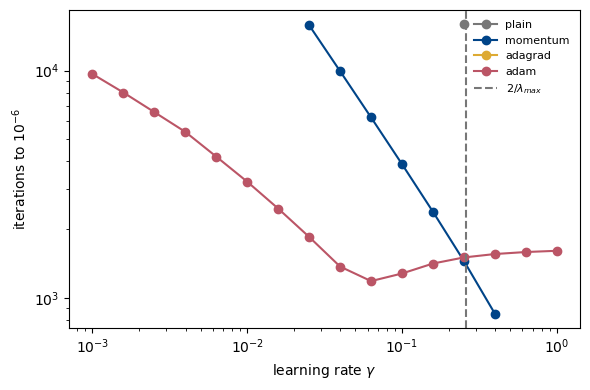

In [ ]:
gammas = np.geomspace(1e-3, 1.0, 16)
fig, ax = plt.subplots(figsize=(6, 4))
for method in ('plain', 'momentum', 'adagrad', 'adam'):
    its = []
    for g in gammas:
        with np.errstate(over='ignore', invalid='ignore'):
            hist, _ = optimise(grad_fn, np.zeros(Xtr.shape[1]), method, g, num_iters=20000, tol=0.0)
        k = iters_to(hist)
        its.append(np.nan if k is None else k)
    ax.loglog(gammas, its, 'o-', color=cols[method], label=method)
ax.axvline(2 / hessian_eigs(Xtr).max(), ls='--', color=GREY, label=r'$2/\lambda_{max}$')
ax.set_xlabel(r'learning rate $\gamma$')
ax.set_ylabel('iterations to $10^{-6}$')
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
savefig('f_lr_sensitivity', fig)
plt.show()

Plain gradient descent reaches the tolerance at one grid point only, just below $2/\lambda_{\max}$, and AdaGrad at none, so those two curves are nearly empty. Momentum reaches further and is fastest at its best point, but falls off sharply on either side. Adam converges at every $\gamma$ tested, across three decades, with a shallow optimum near $\gamma = 0.06$. It is the least sensitive to the choice, which is why it transfers well between problems.

## Summary of parts e and f

The analytical and automatic gradients agree to machine precision, so either can drive gradient descent, and the two give identical iterates. Plain gradient descent is governed by the eigenvalues of the Hessian: the step must stay below $2/\lambda_{\max}$ and the iteration count grows with the condition number. Ridge converges faster than OLS because the penalty raises $\lambda_{\min}$ and lowers the condition number, but it converges to a different solution.

Momentum and Adam converge much faster than plain descent on the ill-conditioned degree-6 problem, and Adam tolerates by far the widest range of learning rates. AdaGrad and RMSProp do not reach the tolerance at a constant rate here, although AdaGrad is the best of the five with minibatches in part h.